# Home Credit Default Risk
## https://www.kaggle.com/datasets/megancrenshaw/home-credit-default-risk

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Toda la base de datos

In [ ]:
df = pd.read_csv('application_train.csv')

In [ ]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Cargamos solo las columnas más relevantes

In [ ]:

def load_home_credit_data(file_path):
    cols = [
        'TARGET', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
        'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
    ]

    df = pd.read_csv(file_path, usecols=cols)

    # Preprocesado rápido
    # 1. Convertir género a numérico (Variable Sensible)
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1}).fillna(0)

    # 2. Edad a años positivos
    df['DAYS_BIRTH'] = abs(df['DAYS_BIRTH']) / 365

    # 3. Tratar valores nulos en fuentes externas (clave para la incertidumbre)
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
        df[col] = df[col].fillna(df[col].median())

    # Separar variables
    X = df.drop(columns=['TARGET'])
    y = df['TARGET']
    s = df['CODE_GENDER'] # Guardamos la variable sensible aparte para la Loss Custom

    # Split
    X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
        X, y, s, test_size=0.2, random_state=42
    )

    # Escalado
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return (X_train, y_train, s_train), (X_test, y_test, s_test)



In [ ]:
# Uso:
(X_train, y_train, s_train), (X_test, y_test, s_test) = load_home_credit_data('application_train.csv')

In [ ]:
import numpy as np

# Ensure y_train and s_train are 2D arrays for stacking
y_train_reshaped = y_train.values.reshape(-1, 1)

# Combine X_train, y_train, and s_train into a single matrix
combined_data_train = np.hstack((X_train, y_train_reshaped))

print("Shape of the combined training data matrix:", combined_data_train.shape)
print("First 5 rows of the combined training data matrix:\n", combined_data_train[:5,:])

Shape of the combined training data matrix: (4631, 9)
First 5 rows of the combined training data matrix:
 [[ 7.15828324e-01  1.52570488e+00  8.30746626e-01  1.72962310e+00
  -1.39086433e+00 -2.47467022e-03  5.83152681e-02  8.50609720e-02
   0.00000000e+00]
 [ 7.15828324e-01 -6.54533411e-01  1.26659654e+00  3.71848548e-01
  -1.74520225e-02 -2.01871065e-01  9.89507792e-01  8.50609720e-02
   0.00000000e+00]
 [ 7.15828324e-01 -9.78768256e-02  8.67375208e-01  5.49824032e-02
   1.83169140e-01  2.65576517e-02  5.16895026e-01 -1.74566942e-01
   0.00000000e+00]
 [ 7.15828324e-01 -9.78768256e-02 -8.67787775e-01 -7.23120852e-01
  -3.22273440e-02  2.65576517e-02  3.75372478e-01 -4.84113581e-01
   0.00000000e+00]
 [-1.39698300e+00  3.66003663e-01  3.21639429e+00  1.74493518e+00
   6.08652226e-01  2.65576517e-02  9.39056017e-01  1.69318223e+00
   0.00000000e+00]]


In [ ]:
print(X_train.shape)
print(y_train.shape)
print(s_train.shape)
print(combined_data_train.shape)

(4631, 8)
(4631,)
(4631,)
(4631, 9)


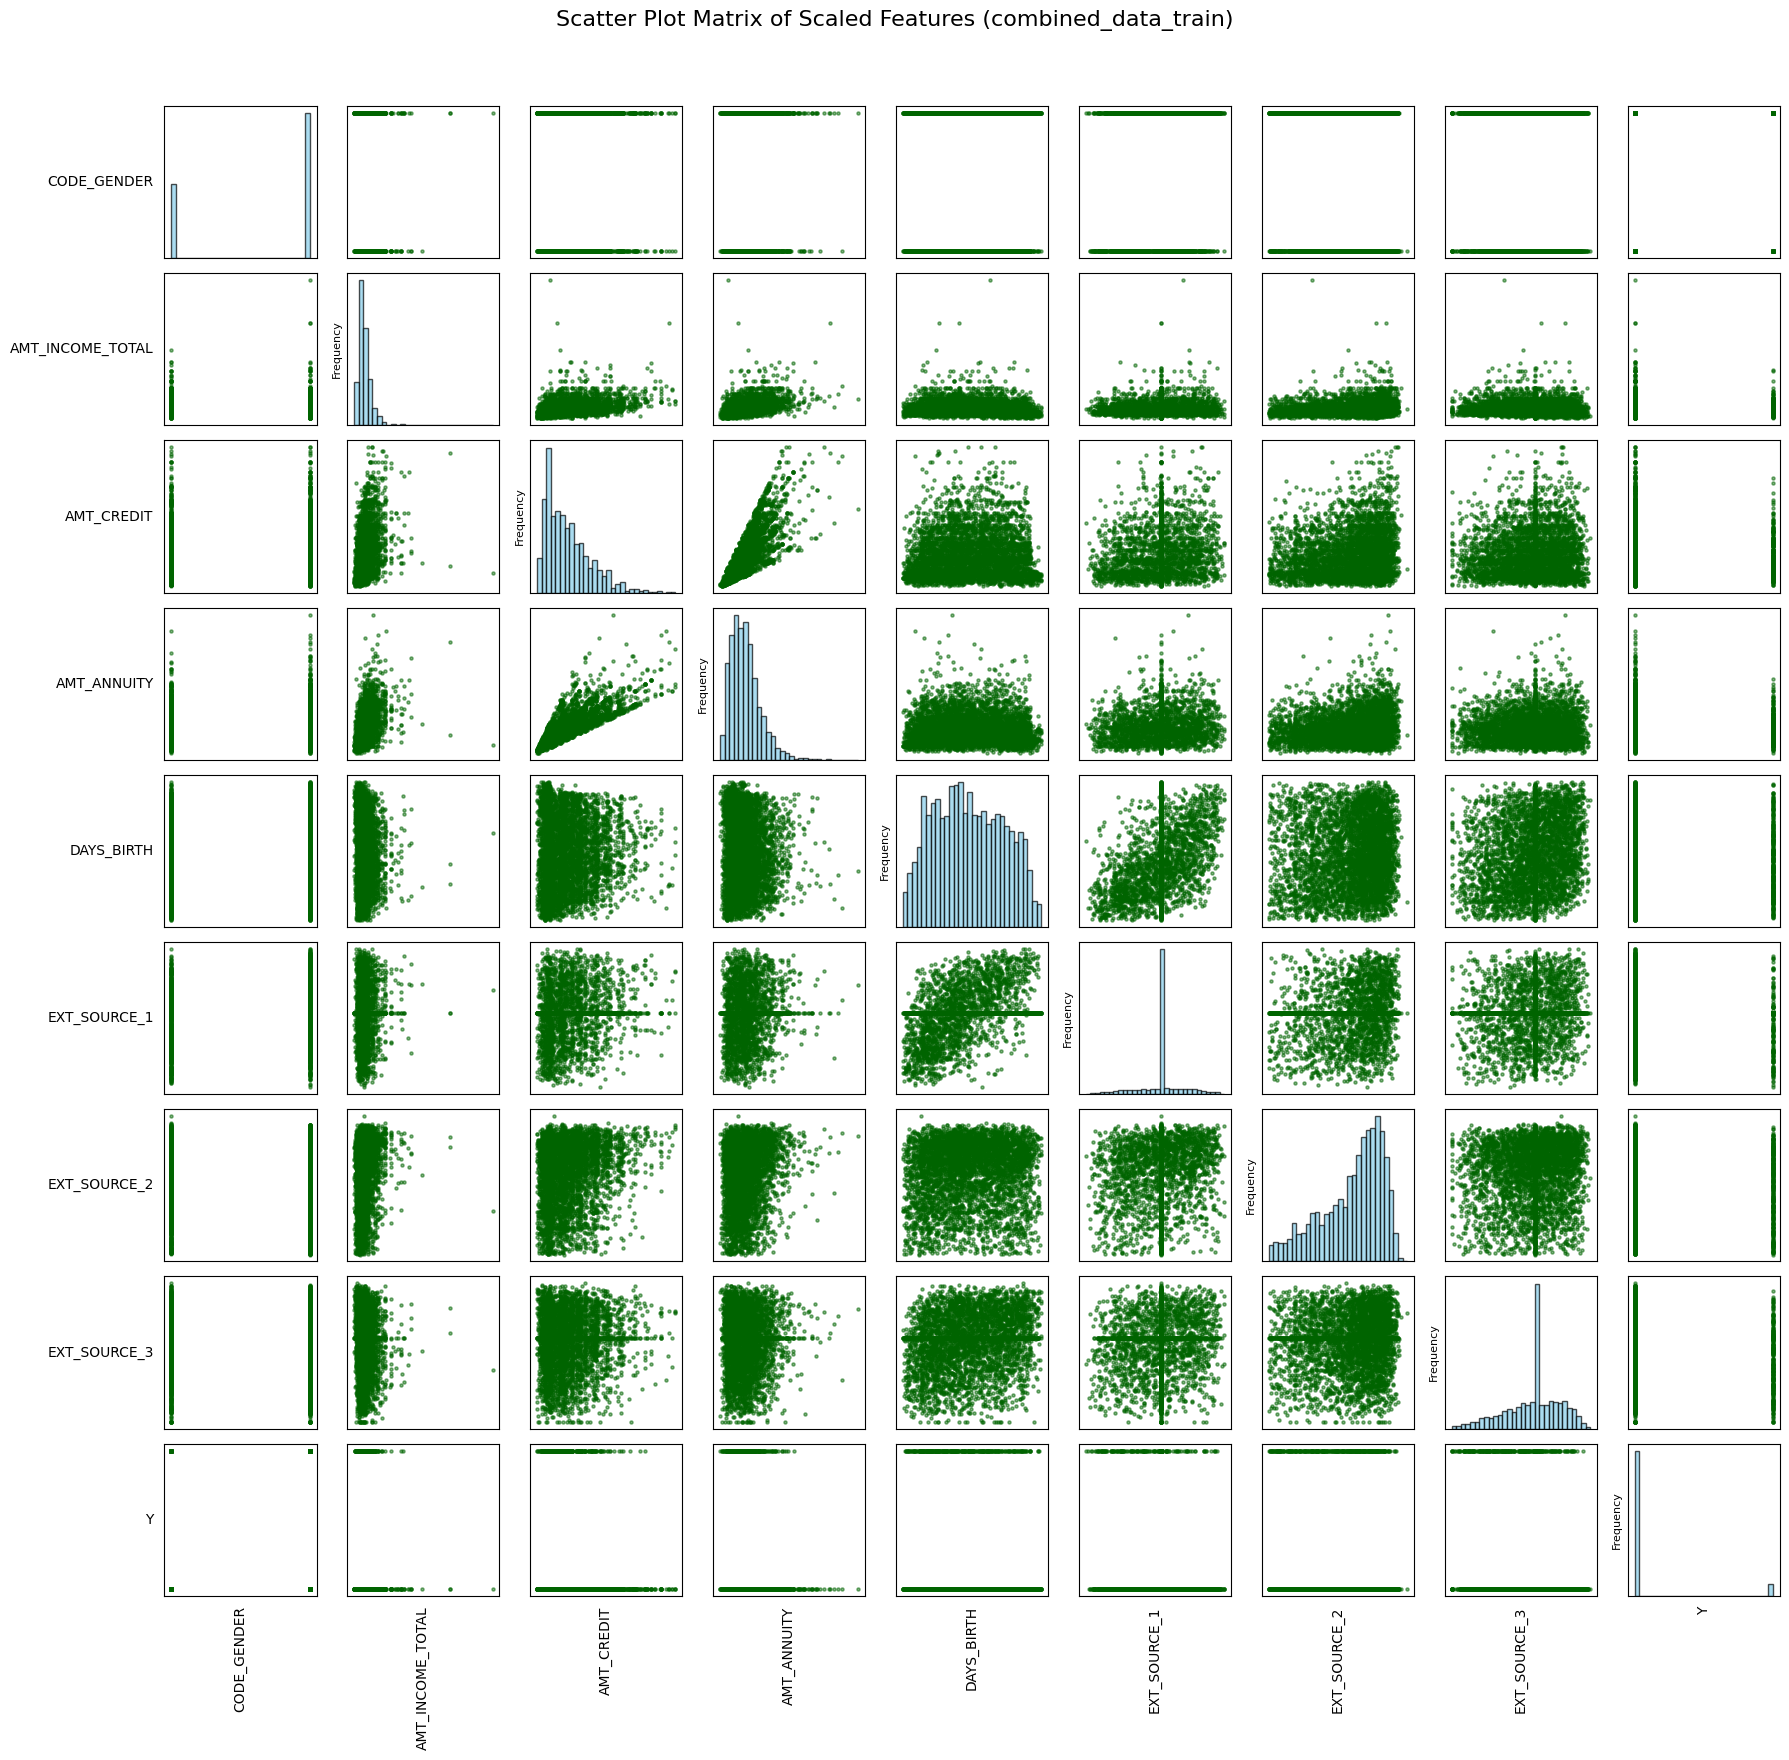

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reconstruct column names for better labels, assuming the order from load_home_credit_data function
feature_names = [
    'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3','Y'
]

n_features = combined_data_train.shape[1]
fig, axes = plt.subplots(n_features, n_features, figsize=(18, 18))

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            # On diagonal, plot histogram
            ax.hist(combined_data_train[:, i], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
            ax.set_ylabel('Frequency', fontsize=8)
        else:
            # Off-diagonal, plot scatter plot
            ax.scatter(combined_data_train[:, j], combined_data_train[:, i], alpha=0.5, s=5, color='darkgreen')
            ax.set_aspect('auto')

        # Set labels for the outer plots only
        if i == n_features - 1: # Bottom row
            ax.set_xlabel(feature_names[j], rotation=90, ha='center', fontsize=10)
        else:
            ax.set_xticks([])

        if j == 0: # Leftmost column
            ax.set_ylabel(feature_names[i], rotation=0, ha='right', va='center', fontsize=10)
        else:
            ax.set_yticks([])

        # Remove ticks for all inner plots
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

plt.suptitle('Scatter Plot Matrix of Scaled Features (combined_data_train)', y=1.005, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()